In [14]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import SAGEConv, GraphConv, GATConv, to_hetero
from torch_geometric.data import HeteroData
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import roc_auc_score # Common metric for link prediction
import matplotlib.pyplot as plt

import os
import numpy as np
import json
import pandas as pd
import optuna

from utils.hake_dataset import invert_nested_dict
from utils.utils import *

In [15]:
from torch_geometric import seed_everything
seed_everything(4444)

In [ ]:
DATA_PATH = './data'

# folder to save entity id mapping
ID_MAPPING = os.path.join(DATA_PATH, 'entity_id_map')
os.makedirs(ID_MAPPING, exist_ok=True)

# folder to save edge index
EDGE_INDEX = os.path.join(DATA_PATH, 'edge_index')
os.makedirs(EDGE_INDEX, exist_ok=True)

# folder to save graph data
GRAPH_DATA = os.path.join(DATA_PATH, 'graph_data')
os.makedirs(GRAPH_DATA, exist_ok=True)

# folder to save model checkpoints
CHECKPOINT_PATH = './checkpoints'
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# 0. Load data

## 0.1. Add reverse edge types and localize index for link prediction model

In [ ]:
# load data
data = torch.load(os.path.join(GRAPH_DATA, 'yfinance_kge_full.pt'), weights_only=False)

id_mapping_path = os.path.join(ID_MAPPING, 'global_id.json')

EDGE_TYPES_ORIGINAL = [
    ('company', 'has_symbol', 'stock_symbol'),
    ('company', 'belongs_to', 'industry'),
    ('industry', 'is_part_of', 'sector'),
    ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
    ('fund', 'has_symbol', 'fund_symbol'),
]

data, _, FINAL_EDGE_TYPES = localize_and_create_inverse_edges(data, id_mapping_path, EDGE_TYPES_ORIGINAL)

Starting localization of edge indices and creating inverse relations...
✅ Localization complete. Forward edge types: 6, Total edge types: 12


## 0.2. Split the features

In [ ]:
HAKE_EMBED_DIM = 32
# Define a minimal constant dimension for nodes that inherently lack fixed features
DEFAULT_FIXED_DIM = 1 
DEFAULT_FIXED_VALUE = 1.0

data = split_and_prepare_features(data, HAKE_EMBED_DIM, DEFAULT_FIXED_DIM, DEFAULT_FIXED_VALUE)

Starting feature split (HAKE D=32, Placeholder D=1)...
  - company: Split features. D_fixed=38.
  - fund_symbol: Split features. D_fixed=29.
  - sector: Split features. D_fixed=7.
  - industry: Split features. D_fixed=9.
  - stock_symbol: Only HAKE found. Assigned default fixed_x (D=1).
  - institution: Only HAKE found. Assigned default fixed_x (D=1).
  - fund: Only HAKE found. Assigned default fixed_x (D=1).
✅ Feature preparation complete.


# 1. Define Feature Manager module

In [ ]:
class FeatureManager(nn.Module):
    def __init__(self, data):
        super().__init__()
        
        self.embedding_layers = nn.ModuleDict()
        self.fixed_features = nn.ParameterDict()
        self.node_types = data.node_types
        
        for ntype in self.node_types:
            
            # --- Trainable HAKE Embeddings (nn.Embedding) ---
            if hasattr(data[ntype], 'hake_embeds'):
                hake_tensor = data[ntype].hake_embeds
                N_nodes, D_hake = hake_tensor.shape
                
                # Create trainable nn.Embedding layer, initialized with HAKE weights
                embed_layer = nn.Embedding(N_nodes, D_hake)
                embed_layer.weight.data.copy_(hake_tensor.to(dtype=torch.float))
                self.embedding_layers[ntype] = embed_layer

            # --- Fixed Original Features (nn.Parameter(requires_grad=False)) ---
            if hasattr(data[ntype], 'fixed_x'):
                fixed_tensor = data[ntype].fixed_x
                # Wrap as fixed Parameter, requires_grad=False is CRITICAL here
                fixed_param = nn.Parameter(fixed_tensor.to(dtype=torch.float), requires_grad=False)
                self.fixed_features[ntype] = fixed_param
                
    def forward(self, idx_dict, device):
        """Combines and returns the final feature dictionary for the GNN."""
        x_dict = {}
        for ntype in self.node_types:
            
            fixed_x = self.fixed_features.get(ntype)
            
            # 1. Get trainable HAKE embeddings
            if ntype in self.embedding_layers:
                hake_indices = idx_dict[ntype].to(device)
                trainable_hake_x = self.embedding_layers[ntype](hake_indices)
                
                # 2. Concatenate
                if fixed_x is not None:
                    x_dict[ntype] = torch.cat([fixed_x, trainable_hake_x], dim=-1)
                else:
                    x_dict[ntype] = trainable_hake_x
            
            elif fixed_x is not None:
                 # Case where only fixed features exist (e.g., if D_hake=0 for a node type)
                 x_dict[ntype] = fixed_x
                 
        return x_dict

# 2. Define GNN Encoder

In [ ]:
CONV_LAYERS = {
    'SAGE': SAGEConv,
    'GCN': GraphConv, 
    'GAT': GATConv,
}

class GNNEncoder(nn.Module):
    def __init__(self, 
                 out_channels: int, 
                 num_layers: int = 2, 
                 conv_class: str = 'SAGE', 
                 dropout: float = 0.5,
                 heads: int = 4): 
        """
        Initializes a flexible GNN encoder suitable for wrapping with to_hetero.

        Args:
            out_channels (int): The hidden dimension size.
            num_layers (int): The number of convolutional layers.
            conv_class (str): The type of GNN layer ('SAGE', 'GCN', 'GAT').
            dropout (float): Dropout rate.
            heads (int): Number of attention heads (used only for GAT).
        """
        super().__init__()
        
        self.num_layers = num_layers
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        self.heads = heads
        
        ConvLayer = CONV_LAYERS.get(conv_class)
        if ConvLayer is None:
            raise ValueError(f"Unknown convolution type: {conv_class}. Choose from {list(CONV_LAYERS.keys())}")
            
        self.convs = nn.ModuleList()

        # Build the stack of layers
        for i in range(num_layers):
            # All layers (SAGE, GAT, GraphConv) are compatible with the 
            # tuple format (-1, -1) for lazy initialization.
            in_arg = (-1, -1) 
        
            if ConvLayer is GATConv:
                if i < num_layers - 1:
                    # Hidden layers: Use concat=True to combine head outputs. 
                    out_dim = out_channels // heads 
                    conv = GATConv(in_arg, out_dim, heads=heads, concat=True, add_self_loops=False)
                else:
                    # Final layer: Use concat=False to return a single vector of size `out_channels`.
                    conv = GATConv(in_arg, out_channels, heads=heads, concat=False, add_self_loops=False)
            
            else: # SAGEConv or GraphConv (GCN)
                # These layers simply use the full output dimension.
                conv = ConvLayer(in_arg, out_channels,) 

            self.convs.append(conv)

        
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for the homogeneous GNN.
        """
        
        # Loop through all layers
        for i, conv in enumerate(self.convs):
            
            x = conv(x, edge_index)
            
            # 🛑 CRITICAL FIX: Only apply activation and dropout before the final layer.
            # The final layer's output (embedding) should typically be raw.
            if i < self.num_layers - 1 or self.num_layers == 1: # Apply only to hidden layers
                x = self.act(x)
                x = self.dropout(x)
                
        # The output of the final layer (x) is the node embedding
        return x

# 3. Define Link predictor (decoder)

In [ ]:
class EdgeDecoder(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, z_src, z_dst, edge_label_index):
        # Retrieve the embeddings for the edges' source and destination nodes
        src, dst = edge_label_index
        z_src = z_src[src]
        z_dst = z_dst[dst]
        
        # Calculate the score (e.g., dot product)
        score = torch.sum(z_src * z_dst, dim=-1)
        return score

# 4. Training and eval functions

In [ ]:
def split_data(data, num_val, num_test, neg_sampling_ratio, is_undirected, edge_types, rev_edge_types):
    transform = RandomLinkSplit(
        num_val=num_val,
        num_test=num_test,
        neg_sampling_ratio=neg_sampling_ratio,
        is_undirected=is_undirected,
        edge_types=edge_types,
        rev_edge_types=rev_edge_types,
    )
    train_data, val_data, test_data = transform(data)
    return train_data, val_data, test_data

In [ ]:
def get_encoder_inputs(data_split, device):
    """
    Prepares the index dictionary required by the FeatureManager.
    
    Args:
        data_split (HeteroData): train_data, val_data, or test_data.
        device (torch.device): The device the tensors should be on.
    
    Returns:
        tuple: (edge_index_dict, idx_dict)
    """
    idx_dict = {}
    
    # Iterate over all node types in the data split
    for ntype in data_split.node_types:
        # Get the index tensor for the FeatureManager's nn.Embedding lookup
        # This attribute (idx) was created during your data preparation step.
        if hasattr(data_split[ntype], 'idx'):
            idx_dict[ntype] = data_split[ntype].idx.to(device)
            
    # Return the graph structure (edge indices) and the node indices
    return data_split.edge_index_dict, idx_dict

In [ ]:
def train(train_data, feature_manager, hetero_model, predictor, optimizer, edge_types, criterion, device):
    """
    Performs a single training epoch using the FeatureManager for feature generation.
    """
    feature_manager.train()
    hetero_model.train()
    predictor.train()
    optimizer.zero_grad()
    
    # 1. Prepare inputs (get the graph structure and the indices)
    edge_index_dict, idx_dict = get_encoder_inputs(train_data, device)
    
    # 2. Feature Generation (HAKE lookup and concatenation with fixed features)
    # x_dict is the final combined feature dictionary ready for the GNN
    x_dict = feature_manager(idx_dict, device) 
    
    # 3. GNN Forward Pass
    z_dict = hetero_model(x_dict, edge_index_dict)
    
    total_loss = 0
    
    # 4. Link Prediction and Loss Calculation (using forward EDGE_TYPES only)
    for edge_type in edge_types:
        
        edge_label_index = train_data[edge_type].edge_label_index.to(device)
        edge_labels = train_data[edge_type].edge_label.float().to(device)

        src_type, _, dst_type = edge_type
        
        scores = predictor(
            z_dict[src_type], 
            z_dict[dst_type], 
            edge_label_index
        )

        loss = criterion(scores, edge_labels)
        total_loss += loss
        
    # 5. Backpropagation
    total_loss.backward()
    
    optimizer.step()
    
    return total_loss.item()

In [ ]:
@torch.no_grad()
def evaluate(data_split, feature_manager, hetero_model, predictor, edge_types, criterion, device):
    """
    Evaluates the model and returns the total loss and AUC score.
    """
    feature_manager.eval()
    hetero_model.eval()
    predictor.eval()

    # 1. Prepare inputs (get the graph structure and the indices)
    edge_index_dict, idx_dict = get_encoder_inputs(data_split, device)
    
    # 2. Feature Generation
    x_dict = feature_manager(idx_dict, device)
    
    # 3. GNN Forward Pass
    z_dict = hetero_model(x_dict, edge_index_dict)
    
    total_loss = 0
    all_scores = []
    all_labels = []

    # 4. Link Prediction and Metrics Calculation
    for edge_type in edge_types:
        
        edge_label_index = data_split[edge_type].edge_label_index.to(device)
        edge_labels = data_split[edge_type].edge_label.float().to(device)
        
        src_type, _, dst_type = edge_type
        
        scores_logits = predictor(
            z_dict[src_type], 
            z_dict[dst_type], 
            edge_label_index
        )
        
        # Calculate loss
        loss = criterion(scores_logits, edge_labels)
        total_loss += loss.item()

        # Collect scores and labels for AUC
        scores_prob = torch.sigmoid(scores_logits)
        all_scores.append(scores_prob.cpu())
        all_labels.append(edge_labels.cpu())

    # 5. Calculate overall AUC
    try:
        y_score = torch.cat(all_scores).view(-1).numpy()
        y_true = torch.cat(all_labels).view(-1).numpy()

        if len(torch.unique(torch.tensor(y_true))) > 1:
            from sklearn.metrics import roc_auc_score
            auc = roc_auc_score(y_true, y_score)
        else:
            auc = 0.5 
            
    except ValueError:
        auc = 0.5

    return total_loss, auc

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, val_aucs):
    """
    Plots the training loss, validation loss, and validation AUC over epochs.

    Args:
        train_losses (list): List of training loss values per epoch.
        val_losses (list): List of validation loss values per epoch.
        val_aucs (list): List of validation AUC scores per epoch.
    """
    
    # Calculate the number of epochs from the length of the logged lists
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    # --- Plot 1: Loss Curve (Train vs. Validation) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', linestyle='-')
    plt.plot(epochs, val_losses, label='Validation Loss', linestyle='--')
    
    plt.title('Loss Curve Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True, alpha=0.5)

    # --- Plot 2: AUC Curve (Validation Metric) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_aucs, label='Train AUC', ls='-')
    plt.plot(epochs, val_aucs, label='Validation AUC', ls='-')
    
    plt.title('AUC Score')
    plt.xlabel('Epoch')
    plt.ylabel('AUC Score')
    plt.ylim(0.0, 1.0) # AUC scores are between 0 and 1
    plt.legend()
    plt.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

# 5. Function to run hyperparameter tuning loop

In [ ]:
def hyperparam_tuning_optuna(n_trials, data, edge_types, rev_edge_types, logging_frequency, checkpoint_path, search_space, eval_frequency=5):
    """
    Optuna-based hyperparameter tuning for link prediction with Hyperband pruning.
    
    Args:
        n_trials (int): Number of trials for Optuna to run
        data: The graph data
        edge_types: Edge types to predict
        rev_edge_types: Reverse edge types
        logging_frequency (int): How often to log during training
        checkpoint_path (str): Path to save best model
        search_space (dict): Dictionary defining the search space for each hyperparameter
        eval_frequency (int): Evaluate every N epochs (default 5)
    """
    
    # Prepare the metadata for model initialization
    metadata = data.metadata()
    
    # Global variables to track best model across all trials
    best_auc = -1.0
    best_params = None
    best_model_states = None  # Store best model weights
    
    # Store all trial results
    all_results = []
    
    # Extract max_epochs bounds from search space for Hyperband configuration
    max_epochs_config = search_space.get('max_epochs', {'low': 50, 'high': 1000})
    min_resource = max_epochs_config['low']
    max_resource = max_epochs_config['high']
    
    def objective(trial):
        nonlocal best_auc, best_params, best_model_states
        
        # Sample hyperparameters from the search space
        params = {}
        for param_name, param_config in search_space.items():
            if param_config['type'] == 'categorical':
                params[param_name] = trial.suggest_categorical(param_name, param_config['choices'])
            elif param_config['type'] == 'int':
                if 'step' in param_config:
                    params[param_name] = trial.suggest_int(param_name, param_config['low'], param_config['high'], step=param_config['step'])
                else:
                    params[param_name] = trial.suggest_int(param_name, param_config['low'], param_config['high'])
            elif param_config['type'] == 'float':
                params[param_name] = trial.suggest_float(param_name, param_config['low'], param_config['high'], log=param_config.get('log', False))
        
        # --- Constraint: For GAT, ensure out_channels >= heads ---
        # This prevents the error where out_channels // heads = 0
        if params['conv_type'] == 'GAT' and params['out_channels'] < params['heads']:
            # Skip this invalid configuration by raising TrialPruned
            print(f"\n  Skipping invalid config: GAT with out_channels={params['out_channels']} < heads={params['heads']}")
            raise optuna.TrialPruned()
        
        # --- Configuration Logging ---
        print("\n" + "=" * 60)
        print(f"Trial {trial.number + 1}:")
        print("-" * 60)
        for key, value in params.items():
            if isinstance(value, float):
                print(f"  {key.replace('_', ' ').title():<20s}: {value:.6f}")
            else:
                print(f"  {key.replace('_', ' ').title():<20s}: {value}")
        print("-" * 60)
    
        # ---- data split -----
        data_device = data.to(device)
        
        train_data, val_data, _ = split_data(data_device, 
                                             num_val=params['num_val'], 
                                             num_test=params['num_val'], 
                                             neg_sampling_ratio=1.0, 
                                             is_undirected=False, 
                                             edge_types=edge_types,
                                             rev_edge_types=rev_edge_types,
                                            )
        
        # --- 1. Model Initialization ---
        feature_manager = FeatureManager(data_device).to(device)
        
        gnn_encoder = GNNEncoder(
            out_channels=params['out_channels'],
            num_layers=params['num_layers'],
            conv_class=params['conv_type'],
            dropout=params['dropout'],
            heads=params['heads'],
        ).to(device)
        
        hetero_model = to_hetero(gnn_encoder, metadata, aggr='sum').to(device)
        predictor = EdgeDecoder().to(device)
        
        optimizer = torch.optim.Adam(
            list(feature_manager.parameters()) + list(hetero_model.parameters()) + list(predictor.parameters()), 
            lr=params['learning_rate'],
            weight_decay=params['weight_decay']
        )
        criterion = torch.nn.BCEWithLogitsLoss()
    
        # Track best validation AUC for this trial
        best_val_auc_for_trial = -1.0
        best_val_loss_for_trial = float('inf')
        best_epoch_for_trial = 0
        
        # Store best model states for this trial
        trial_best_states = None
        
        # Get max_epochs from params
        max_epochs = params['max_epochs']
        
        # --- 2. Training and Evaluation ---
        for epoch in range(1, max_epochs + 1):
            
            # Train
            train(train_data, feature_manager, hetero_model, predictor, optimizer, edge_types, criterion, device)
            
            # Evaluate every eval_frequency epochs (or at the last epoch)
            if epoch % eval_frequency == 0 or epoch == max_epochs:
                # Evaluate
                train_loss_eval, train_auc = evaluate(train_data, feature_manager, hetero_model, predictor, edge_types, criterion, device)
                val_loss, val_auc = evaluate(val_data, feature_manager, hetero_model, predictor, edge_types, criterion, device)
                
                # Report intermediate value to Optuna for Hyperband pruning
                trial.report(val_auc, epoch)
                
                # Check if trial should be pruned
                if trial.should_prune():
                    print(f"  Trial pruned at epoch {epoch}")
                    raise optuna.TrialPruned()
                
                # Track best validation AUC for this trial and save model states
                if val_auc > best_val_auc_for_trial:
                    best_val_auc_for_trial = val_auc
                    best_val_loss_for_trial = val_loss
                    best_epoch_for_trial = epoch
                    # Save model states at best epoch
                    trial_best_states = {
                        'feature_manager_state': {k: v.cpu().clone() for k, v in feature_manager.state_dict().items()},
                        'hetero_model_state': {k: v.cpu().clone() for k, v in hetero_model.state_dict().items()},
                        'predictor_state': {k: v.cpu().clone() for k, v in predictor.state_dict().items()},
                    }

                # --- Logging ---
                if epoch % logging_frequency == 0 or epoch == max_epochs:
                     print(f"  Epoch: {epoch:03d}/{max_epochs}, Train Loss: {train_loss_eval:.4f}, Train AUC: {train_auc:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")
    
        # --- 3. Record Results ---
        result = params.copy()
        result['final_val_auc'] = best_val_auc_for_trial
        result['final_val_loss'] = best_val_loss_for_trial
        result['best_epoch'] = best_epoch_for_trial
        result['trial_number'] = trial.number
        all_results.append(result)
    
        # Check if this is the best model overall
        if best_val_auc_for_trial > best_auc:
            best_auc = best_val_auc_for_trial
            best_params = params.copy()
            best_model_states = trial_best_states
            print(f"\n*** New BEST Model Found! Val AUC: {best_auc:.4f} (at epoch {best_epoch_for_trial}) ***")
            print("-" * 60)
    
            # Save checkpoint
            checkpoint = {
                'params': best_params,
                'feature_manager_state': best_model_states['feature_manager_state'],
                'hetero_model_state': best_model_states['hetero_model_state'],
                'predictor_state': best_model_states['predictor_state'],
                'best_val_auc': best_auc,
                'best_epoch': best_epoch_for_trial,
                'trial_number': trial.number
            }
            torch.save(checkpoint, checkpoint_path)
        else:
            print("-" * 60)
    
        return best_val_auc_for_trial
    
    # Create Optuna study with Hyperband pruner
    print(f"\nStarting Optuna hyperparameter search with {n_trials} trials...")
    print(f"Using Hyperband pruner (min_resource={min_resource}, max_resource={max_resource}, reduction_factor=3)")
    print(f"Evaluating every {eval_frequency} epochs")
    
    study = optuna.create_study(
        direction='maximize',
        pruner=optuna.pruners.HyperbandPruner(
            min_resource=min_resource,      # Minimum epochs before pruning (matches max_epochs low bound)
            max_resource=max_resource,      # Maximum epochs (matches max_epochs high bound)
            reduction_factor=3              # Standard Successive Halving factor
        )
    )
    
    # Optimize
    study.optimize(objective, n_trials=n_trials)
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values(by='final_val_auc', ascending=False)
    
    # --- Final Output ---
    print("\n" + "=" * 60)
    print("Optuna Hyperparameter Search Complete")
    print("=" * 60)
    print(f"Total Trials Completed: {len(study.trials)}")
    print(f"Best Trial Number: {study.best_trial.number}")
    print(f"Overall Best Validation AUC: {best_auc:.4f}")
    print("\nBest Parameters:")
    for key, value in best_params.items():
        if isinstance(value, float):
            print(f"  - {key.replace('_', ' ').title()}: {value:.6f}")
        else:
            print(f"  - {key.replace('_', ' ').title()}: {value}")
    print("=" * 60)

    return results_df, study

# 6. Function to evaluate best model on test set

In [ ]:
def evaluate_best_model(checkpoint_path, data, device, edge_types, rev_edge_types):
    # 0. Prepare the metadata for model initialization
    # Extract Shape Information
    hake_shapes = {}
    fixed_x_shapes = {}
    for ntype in data.node_types:
        if hasattr(data[ntype], 'hake_embeds'):
            N, D_hake = data[ntype].hake_embeds.shape
            hake_shapes[ntype] = (N, D_hake)
        if hasattr(data[ntype], 'fixed_x'):
            D_fixed = data[ntype].fixed_x.shape[1]
            fixed_x_shapes[ntype] = D_fixed
    
    # Get the Metadata (contains all node and edge types)
    metadata = data.metadata()
    
    # 1. Load the checkpoint file
    if not os.path.exists(checkpoint_path):
        print(f"Error: Checkpoint {checkpoint_path} not found.")
        return
    
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    params = checkpoint['params']

    # data split 
    data = data.to(device)
    
    _, _, test_data = split_data(data, 
                                 num_val=params['num_val'], 
                                 num_test=params['num_val'], 
                                 neg_sampling_ratio=1.0, 
                                 is_undirected=False, 
                                 edge_types=edge_types,
                                 rev_edge_types=rev_edge_types,
                                )
    
    print(f"--- Evaluating Best Model ---")
    print(f"Config: {params}")
    # print(f"Best Val AUC recorded: {checkpoint['metrics']['val_auc']:.4f}")

    # 2. Re-initialize the Model components exactly as they were
    # (Using the params dictionary from the checkpoint)
    feature_manager = FeatureManager(data).to(device)
    
    gnn_encoder = GNNEncoder(
        out_channels=params['out_channels'],
        num_layers=params['num_layers'],
        conv_class=params['conv_type'],
        dropout=params.get('dropout', 0.5),  # Use saved dropout or default
        heads=params.get('heads', 4)         # Use saved heads or default
    ).to(device)
    
    hetero_model = to_hetero(gnn_encoder, metadata, aggr='sum').to(device)
    predictor = EdgeDecoder().to(device)

    # 4. Load the saved weights
    feature_manager.load_state_dict(checkpoint['feature_manager_state'])
    hetero_model.load_state_dict(checkpoint['hetero_model_state'])
    predictor.load_state_dict(checkpoint['predictor_state'])
    
    # 5. Final Evaluation on Test Set
    # We use the same evaluate function used during tuning
    test_loss, test_auc = evaluate(
        test_data, 
        feature_manager, 
        hetero_model, 
        predictor, 
        edge_types, 
        torch.nn.BCEWithLogitsLoss(), 
        device
    )
    
    return test_loss, test_auc

# 7. Execution

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device

device(type='cuda')

In [ ]:
# Define EXPANDED search space for Optuna (WIDER BOUNDS for comprehensive exploration)
N_TRIALS = 400     # Number of Optuna trials

SEARCH_SPACE = {
    # Training duration (tunable max epochs)
    'max_epochs': {
        'type': 'int',
        'low': 10,
        'high': 1000,
        'step': 5       
    },
    
    # Architecture parameters
    'num_layers': {
        'type': 'int',
        'low': 1,
        'high': 3  # 3-layer models max (more layers rarely help for this task)
    },
    'conv_type': {
        'type': 'categorical',
        'choices': ['GAT', 'GCN', 'SAGE']
    },
    'out_channels': {
        'type': 'int',
        'low': 8,        # EXPANDED: Was 16, now includes smaller models
        'high': 128,     # EXPANDED: Was 64, now includes larger models
        'step': 8        # Forces multiples of 8: [8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112, 120, 128]
    },
    
    # Regularization
    'dropout': {
        'type': 'float',
        'low': 0.0,      # Keep 0.0 (no dropout is valid)
        'high': 0.8,     # EXPANDED: 0.6 → 0.8 (0.9 is almost always too high)
    },
    
    # Optimization parameters
    'learning_rate': {
        'type': 'float',
        'low': 5e-6,     # EXPANDED: 1e-5 → 5e-6 (slightly lower for very careful training)
        'high': 5e-3,    # EXPANDED: 1e-3 → 5e-3 (higher LR can work with good regularization)
        'log': True      # Log-scale sampling
    },
    'weight_decay': {
        'type': 'float',
        'low': 0.0,      # EXPANDED: 1e-6 → 0.0 (explicitly allow no regularization)
        'high': 1e-2,    # EXPANDED: 1e-3 → 1e-2 (10x higher for strong regularization)
        'log': False     # Linear scale for weight decay (more intuitive)
    },
    
    # Data split
    'num_val': {
        'type': 'float',
        'low': 0.1,      # EXPANDED: 0.15 → 0.1 (more training data option)
        'high': 0.45,    # EXPANDED: 0.4 → 0.45 (more validation data option)
    },
    
    # GAT-specific
    'heads': {
        'type': 'categorical',
        'choices': [1, 2, 4, 8, 16]  # EXPANDED: Added 16 heads option
    }
}

In [ ]:
LOGGING_FREQUENCY = 10 # Print detailed log every 100 epochs

## 7.1. Link prediction between funds and stock symbols

In [ ]:
# only split on the edges we're trying to predict

EDGE_TYPES = [
    # ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    # ('stock_symbol', 'rev_holds', 'institution'),
    ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [ ]:
# run Optuna tuning
checkpoint_path = os.path.join(CHECKPOINT_PATH, 'fund_to_stocksymbol_model_optuna.pt')

results_df, study = hyperparam_tuning_optuna(
    n_trials=N_TRIALS,
    data=data, 
    edge_types=EDGE_TYPES, 
    rev_edge_types=REV_EDGE_TYPES, 
    logging_frequency=LOGGING_FREQUENCY, 
    checkpoint_path=checkpoint_path,
    search_space=SEARCH_SPACE
)

In [ ]:
# save hyperparameter tuning results
results_df.to_csv('./tuning_funds_to_stocksymbol_optuna.csv', index=False)

# optionally save the Optuna study
import joblib
joblib.dump(study, './optuna_study_funds_to_stocksymbol.pkl')

['./optuna_study_funds_to_stocksymbol.pkl']

In [ ]:
# load the best checkpoint and evaluate on test set
checkpoint_path = os.path.join(CHECKPOINT_PATH, 'fund_to_stocksymbol_model_optuna.pt')

test_loss, test_auc = evaluate_best_model(checkpoint_path, data, device, EDGE_TYPES, REV_EDGE_TYPES)

print(f"\nFinal Results on Unseen Test Set:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test AUC:  {test_auc:.4f}")

--- Evaluating Best Model ---
Config: {'max_epochs': 225, 'num_layers': 3, 'conv_type': 'SAGE', 'out_channels': 80, 'dropout': 0.1342760133586926, 'learning_rate': 0.0009511430319856447, 'weight_decay': 0.0013812436768415232, 'num_val': 0.24465299152927122, 'heads': 4}

Final Results on Unseen Test Set:
   Test Loss: 0.9625
   Test AUC:  0.4236


## 7.2. Link prediction between institutions and stock symbols

In [ ]:
# only split on the edges we're trying to predict

EDGE_TYPES = [
    ('institution', 'holds', 'stock_symbol'),
    # ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    ('stock_symbol', 'rev_holds', 'institution'),
    # ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [ ]:
# run Optuna tuning
checkpoint_path = os.path.join(CHECKPOINT_PATH, 'institution_to_stocksymbol_model_optuna.pt')

results_df, study = hyperparam_tuning_optuna(
    n_trials=N_TRIALS,
    data=data, 
    edge_types=EDGE_TYPES, 
    rev_edge_types=REV_EDGE_TYPES, 
    logging_frequency=LOGGING_FREQUENCY, 
    checkpoint_path=checkpoint_path,
    search_space=SEARCH_SPACE
)

In [ ]:
# save hyperparameter tuning results
results_df.to_csv('./tuning_institution_to_stocksymbol_optuna.csv', index=False)

# optionally save the Optuna study
import joblib
joblib.dump(study, './optuna_study_institution_to_stocksymbol.pkl')

In [ ]:
# load the best checkpoint and evaluate on test set
checkpoint_path = os.path.join(CHECKPOINT_PATH, 'institution_to_stocksymbol_model_optuna.pt')

test_loss, test_auc = evaluate_best_model(checkpoint_path, data, device, EDGE_TYPES, REV_EDGE_TYPES)

print(f"\nFinal Results on Unseen Test Set:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test AUC:  {test_auc:.4f}")

## 7.3. Link prediction for both (institutions holds stock symbols) and (fund holds stock symbol) 

In [ ]:
# only split on the edges we're trying to predict

EDGE_TYPES = [
    ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    ('stock_symbol', 'rev_holds', 'institution'),
    ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [ ]:
# run Optuna tuning
checkpoint_path = os.path.join(CHECKPOINT_PATH, 'institution_to_stocksymbol__fund_to_stocksymbol_model_optuna.pt')

results_df, study = hyperparam_tuning_optuna(
    n_trials=N_TRIALS,
    data=data, 
    edge_types=EDGE_TYPES, 
    rev_edge_types=REV_EDGE_TYPES, 
    logging_frequency=LOGGING_FREQUENCY, 
    checkpoint_path=checkpoint_path,
    search_space=SEARCH_SPACE
)

In [ ]:
# save hyperparameter tuning results
results_df.to_csv('./tuning_institution_to_stocksymbol__fund_to_stocksymbol_optuna.csv', index=False)

# optionally save the Optuna study
import joblib
joblib.dump(study, './optuna_study_institution_to_stocksymbol__fund_to_stocksymbol.pkl')

In [ ]:
# load the best checkpoint and evaluate on test set
checkpoint_path = os.path.join(CHECKPOINT_PATH, 'institution_to_stocksymbol__fund_to_stocksymbol_model_optuna.pt')

test_loss, test_auc = evaluate_best_model(checkpoint_path, data, device, EDGE_TYPES, REV_EDGE_TYPES)

print(f"\nFinal Results on Unseen Test Set:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test AUC:  {test_auc:.4f}")

# 8. Hyperparameter Importance Analysis

In [16]:
# Load all Optuna studies
import joblib

studies = {
    'fund_to_stock': joblib.load('./optuna_study_funds_to_stocksymbol.pkl'),
    'institution_to_stock': joblib.load('./optuna_study_institution_to_stocksymbol.pkl'),
    'combined': joblib.load('./optuna_study_institution_to_stocksymbol__fund_to_stocksymbol.pkl'),
}

In [17]:
# Compute fANOVA importance for each study
fanova_results = {}

for name, study in studies.items():
    importance = optuna.importance.get_param_importances(study)
    fanova_results[name] = importance
    
# Create DataFrame
importance_df = pd.DataFrame(fanova_results).round(4)
importance_df['mean'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean', ascending=False)

print("fANOVA Parameter Importance Across All Tasks")
print("=" * 70)
importance_df

fANOVA Parameter Importance Across All Tasks


,fund_to_stock,institution_to_stock,combined,mean
conv_type,0.1134,0.2328,0.4560,0.267400
learning_rate,0.1155,0.0565,0.3313,0.167767
max_epochs,0.1989,0.2220,0.0126,0.144500
num_val,0.3149,0.0427,0.0622,0.139933
weight_decay,0.0777,0.1994,0.0713,0.116133
num_layers,0.1085,0.1228,0.0561,0.095800
dropout,0.0208,0.0507,0.0034,0.024967
out_channels,0.0102,0.0576,0.0029,0.023567
heads,0.0402,0.0155,0.0043,0.020000


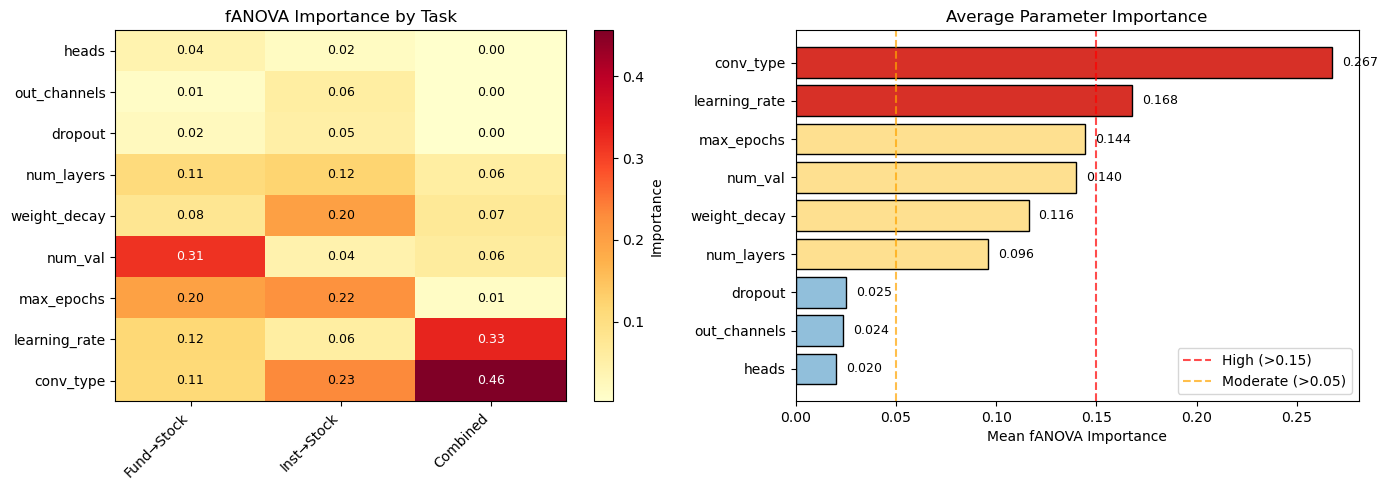

In [18]:
# Visualize parameter importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Heatmap of importance across tasks
ax1 = axes[0]
# Sort by mean first, then drop mean column for plotting
plot_df = importance_df.sort_values('mean', ascending=True).drop(columns=['mean'])
im = ax1.imshow(plot_df.values, cmap='YlOrRd', aspect='auto')
ax1.set_yticks(range(len(plot_df.index)))
ax1.set_yticklabels(plot_df.index)
ax1.set_xticks(range(len(plot_df.columns)))
ax1.set_xticklabels(['Fund→Stock', 'Inst→Stock', 'Combined'], rotation=45, ha='right')
ax1.set_title('fANOVA Importance by Task')

# Add text annotations
for i in range(len(plot_df.index)):
    for j in range(len(plot_df.columns)):
        val = plot_df.iloc[i, j]
        color = 'white' if val > 0.25 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax1, label='Importance')

# Plot 2: Mean importance bar chart
ax2 = axes[1]
mean_importance = importance_df['mean'].sort_values(ascending=True)
colors = ['#d73027' if v > 0.15 else '#fee090' if v > 0.05 else '#91bfdb' for v in mean_importance.values]
bars = ax2.barh(mean_importance.index, mean_importance.values, color=colors, edgecolor='black')
ax2.set_xlabel('Mean fANOVA Importance')
ax2.set_title('Average Parameter Importance')
ax2.axvline(x=0.15, color='red', linestyle='--', alpha=0.7, label='High (>0.15)')
ax2.axvline(x=0.05, color='orange', linestyle='--', alpha=0.7, label='Moderate (>0.05)')
ax2.legend(loc='lower right')

# Add value labels
for bar, val in zip(bars, mean_importance.values):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./fanova_importance_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Print interpretation
print("Parameter Importance Interpretation")
print("=" * 70)
print("""
fANOVA (Functional ANOVA) decomposes the variance of the objective function
to determine how much each hyperparameter contributes to performance variation.

Importance Thresholds:
  > 0.15  : HIGH      - Critical parameter, tune carefully
  0.05-0.15: MODERATE - Worth tuning, has meaningful effect  
  < 0.05  : LOW       - Minimal effect, can use defaults
""")

print("\nRecommendations based on mean importance:")
print("-" * 70)
for param in importance_df.index:
    mean_imp = importance_df.loc[param, 'mean']
    if mean_imp > 0.15:
        priority = "HIGH"
        rec = "Tune carefully"
    elif mean_imp > 0.05:
        priority = "MODERATE" 
        rec = "Worth tuning"
    else:
        priority = "LOW"
        rec = "Use default"
    print(f"  {param:<20s}: {mean_imp:.3f} ({priority:8s}) - {rec}")

Parameter Importance Interpretation

fANOVA (Functional ANOVA) decomposes the variance of the objective function
to determine how much each hyperparameter contributes to performance variation.

Importance Thresholds:
  > 0.15  : HIGH      - Critical parameter, tune carefully
  0.05-0.15: MODERATE - Worth tuning, has meaningful effect  
  < 0.05  : LOW       - Minimal effect, can use defaults


Recommendations based on mean importance:
----------------------------------------------------------------------
  conv_type           : 0.267 (HIGH    ) - Tune carefully
  learning_rate       : 0.168 (HIGH    ) - Tune carefully
  max_epochs          : 0.144 (MODERATE) - Worth tuning
  num_val             : 0.140 (MODERATE) - Worth tuning
  weight_decay        : 0.116 (MODERATE) - Worth tuning
  num_layers          : 0.096 (MODERATE) - Worth tuning
  dropout             : 0.025 (LOW     ) - Use default
  out_channels        : 0.024 (LOW     ) - Use default
  heads               : 0.020 (LOW     )

## 8.1 Study Statistics and Best Parameters

In [20]:
# Summary statistics for each study
print("Optuna Study Statistics")
print("=" * 70)

for name, study in studies.items():
    completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    
    print(f"\n{name}:")
    print(f"  Total trials: {len(study.trials)}")
    print(f"  Completed: {completed} ({100*completed/len(study.trials):.1f}%)")
    print(f"  Pruned: {pruned} ({100*pruned/len(study.trials):.1f}%)")
    print(f"  Best AUC: {study.best_value:.4f}")
    print(f"  Best params:")
    for k, v in study.best_params.items():
        if isinstance(v, float):
            print(f"    {k}: {v:.6f}")
        else:
            print(f"    {k}: {v}")

Optuna Study Statistics

fund_to_stock:
  Total trials: 400
  Completed: 123 (30.8%)
  Pruned: 277 (69.2%)
  Best AUC: 0.9687
  Best params:
    max_epochs: 430
    num_layers: 3
    conv_type: SAGE
    out_channels: 40
    dropout: 0.142001
    learning_rate: 0.002165
    weight_decay: 0.000149
    num_val: 0.122166
    heads: 8

institution_to_stock:
  Total trials: 400
  Completed: 73 (18.2%)
  Pruned: 327 (81.8%)
  Best AUC: 0.9428
  Best params:
    max_epochs: 565
    num_layers: 2
    conv_type: SAGE
    out_channels: 120
    dropout: 0.587784
    learning_rate: 0.003550
    weight_decay: 0.000040
    num_val: 0.145448
    heads: 1

combined:
  Total trials: 400
  Completed: 124 (31.0%)
  Pruned: 276 (69.0%)
  Best AUC: 0.9565
  Best params:
    max_epochs: 595
    num_layers: 2
    conv_type: SAGE
    out_channels: 32
    dropout: 0.230055
    learning_rate: 0.003871
    weight_decay: 0.000104
    num_val: 0.100053
    heads: 8


## 8.2 Categorical Parameter Analysis

In [21]:
# Analyze categorical parameters across all tasks
csv_files = {
    'fund_to_stock': './tuning_funds_to_stocksymbol_optuna.csv',
    'institution_to_stock': './tuning_institution_to_stocksymbol_optuna.csv',
    'combined': './tuning_institution_to_stocksymbol__fund_to_stocksymbol_optuna.csv',
}

# Load and combine all results
all_results = []
for name, path in csv_files.items():
    df = pd.read_csv(path)
    df['task'] = name
    all_results.append(df)

combined_df = pd.concat(all_results, ignore_index=True)

# Analyze conv_type performance
print("Conv Type Performance (aggregated across all tasks)")
print("=" * 70)
conv_stats = combined_df.groupby('conv_type')['final_val_auc'].agg(['mean', 'std', 'count'])
conv_stats = conv_stats.sort_values('mean', ascending=False)
print(conv_stats)
print(f"\nConclusion: {conv_stats.index[0]} performs best on average")

Conv Type Performance (aggregated across all tasks)
               mean       std  count
conv_type                           
SAGE       0.942217  0.023047    305
GCN        0.807882  0.070313      9
GAT        0.806595  0.094967      6

Conclusion: SAGE performs best on average


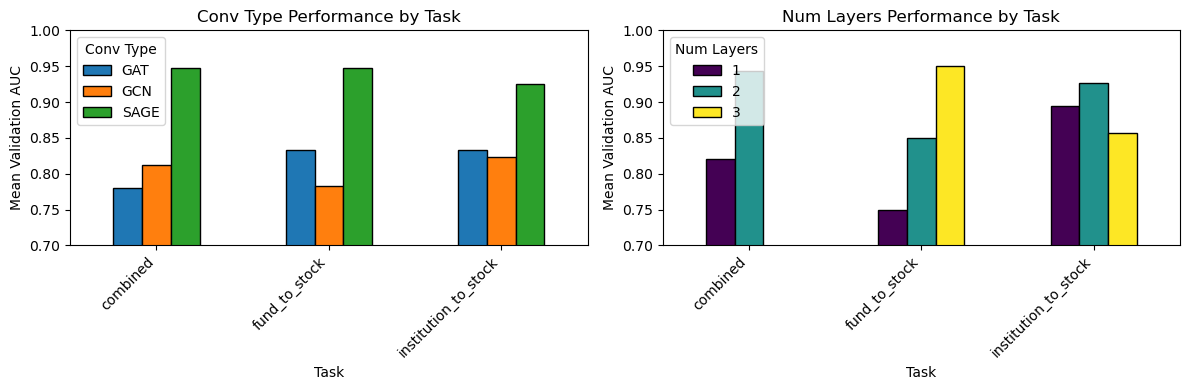

In [22]:
# Visualize conv_type and num_layers performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conv type comparison
ax1 = axes[0]
conv_by_task = combined_df.groupby(['task', 'conv_type'])['final_val_auc'].mean().unstack()
conv_by_task.plot(kind='bar', ax=ax1, edgecolor='black')
ax1.set_xlabel('Task')
ax1.set_ylabel('Mean Validation AUC')
ax1.set_title('Conv Type Performance by Task')
ax1.legend(title='Conv Type')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylim(0.7, 1.0)

# Num layers comparison
ax2 = axes[1]
layers_by_task = combined_df.groupby(['task', 'num_layers'])['final_val_auc'].mean().unstack()
layers_by_task.plot(kind='bar', ax=ax2, edgecolor='black', colormap='viridis')
ax2.set_xlabel('Task')
ax2.set_ylabel('Mean Validation AUC')
ax2.set_title('Num Layers Performance by Task')
ax2.legend(title='Num Layers')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig('./categorical_params_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.3 Correlation Analysis

In [23]:
# Compute correlations between numeric parameters and AUC
from scipy import stats

numeric_params = ['max_epochs', 'num_layers', 'out_channels', 'dropout', 
                  'learning_rate', 'weight_decay', 'num_val', 'heads']

print("Pearson Correlation with Validation AUC (aggregated data)")
print("=" * 70)
print(f"{'Parameter':<20} {'r':>10} {'p-value':>12} {'Significant':>12}")
print("-" * 55)

correlations = {}
for param in numeric_params:
    if param in combined_df.columns:
        r, p = stats.pearsonr(combined_df[param], combined_df['final_val_auc'])
        sig = "Yes" if p < 0.05 else "No"
        correlations[param] = r
        print(f"{param:<20} {r:>+10.4f} {p:>12.2e} {sig:>12}")

print("""
Interpretation:
  |r| > 0.5: Strong correlation
  |r| 0.3-0.5: Moderate correlation  
  |r| < 0.3: Weak correlation
""")

Pearson Correlation with Validation AUC (aggregated data)
Parameter                     r      p-value  Significant
-------------------------------------------------------
max_epochs              +0.1026     6.68e-02           No
num_layers              +0.3243     2.85e-09          Yes
out_channels            -0.1644     3.18e-03          Yes
dropout                 -0.3689     9.46e-12          Yes
learning_rate           +0.2749     5.88e-07          Yes
weight_decay            -0.5766     9.45e-30          Yes
num_val                 -0.4921     6.35e-21          Yes
heads                   +0.0684     2.23e-01           No

Interpretation:
  |r| > 0.5: Strong correlation
  |r| 0.3-0.5: Moderate correlation  
  |r| < 0.3: Weak correlation



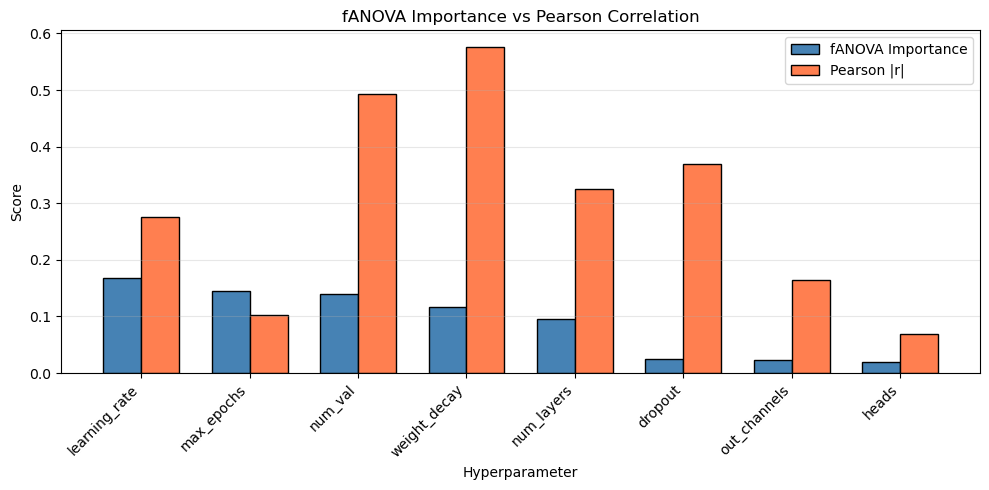


Note: fANOVA and Pearson correlation measure different things:
- Pearson r: Linear relationship strength
- fANOVA: Variance contribution (captures non-linear effects and interactions)

Parameters with high fANOVA but low correlation have non-linear effects.
Parameters with high correlation but low fANOVA have consistent but small effects.



In [24]:
# Compare fANOVA importance vs Pearson correlation
comparison_df = pd.DataFrame({
    'fANOVA': importance_df['mean'],
    'Pearson |r|': pd.Series(correlations).abs()
}).dropna()

comparison_df = comparison_df.sort_values('fANOVA', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['fANOVA'], width, label='fANOVA Importance', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['Pearson |r|'], width, label='Pearson |r|', color='coral', edgecolor='black')

ax.set_xlabel('Hyperparameter')
ax.set_ylabel('Score')
ax.set_title('fANOVA Importance vs Pearson Correlation')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./fanova_vs_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Note: fANOVA and Pearson correlation measure different things:
- Pearson r: Linear relationship strength
- fANOVA: Variance contribution (captures non-linear effects and interactions)

Parameters with high fANOVA but low correlation have non-linear effects.
Parameters with high correlation but low fANOVA have consistent but small effects.
""")

## 8.4 Save Results

In [25]:
# Save fANOVA importance results
importance_df.to_csv('./fanova_importance_results.csv')
print("Saved fANOVA importance to: ./fanova_importance_results.csv")

# Display final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY: Hyperparameter Tuning Recommendations")
print("=" * 70)

print("\nHigh Priority (tune carefully):")
for param in importance_df.index:
    if importance_df.loc[param, 'mean'] > 0.15:
        print(f"  - {param}: {importance_df.loc[param, 'mean']:.3f}")

print("\nModerate Priority (worth tuning):")
for param in importance_df.index:
    mean_imp = importance_df.loc[param, 'mean']
    if 0.05 < mean_imp <= 0.15:
        print(f"  - {param}: {mean_imp:.3f}")

print("\nLow Priority (use defaults):")
for param in importance_df.index:
    if importance_df.loc[param, 'mean'] <= 0.05:
        print(f"  - {param}: {importance_df.loc[param, 'mean']:.3f}")

print("\nBest configurations found:")
for name, study in studies.items():
    print(f"\n  {name}: AUC = {study.best_value:.4f}")
    print(f"    conv_type: {study.best_params['conv_type']}, num_layers: {study.best_params['num_layers']}")

Saved fANOVA importance to: ./fanova_importance_results.csv

FINAL SUMMARY: Hyperparameter Tuning Recommendations

High Priority (tune carefully):
  - conv_type: 0.267
  - learning_rate: 0.168

Moderate Priority (worth tuning):
  - max_epochs: 0.144
  - num_val: 0.140
  - weight_decay: 0.116
  - num_layers: 0.096

Low Priority (use defaults):
  - dropout: 0.025
  - out_channels: 0.024
  - heads: 0.020

Best configurations found:

  fund_to_stock: AUC = 0.9687
    conv_type: SAGE, num_layers: 3

  institution_to_stock: AUC = 0.9428
    conv_type: SAGE, num_layers: 2

  combined: AUC = 0.9565
    conv_type: SAGE, num_layers: 2
